# GLM-suunnittelumatriisin rakentaminen luottotappio-osuuden (LGD) mallinnukseen PROC GLMMOD:lla

## Yhteenveto

Pankin kvantitatiivinen riskienhallintatiimi tarvitsee regressiovalmiin suunnittelumatriisin luottotappio-osuuden (loss-given-default, LGD) mallille, jonka selittäjinä ovat luokitteleva luottoluokka ja alue, jatkuvat velka-tulosuhde (DTI) ja lainan koko sekä luottoluokan ja DTI:n yhdysvaikutus. **PROC GLMMOD** GLM-koodaa nämä luokittelevat, jatkuvat ja yhdysvaikutustermit numeerisiksi sarakkeiksi, jotka syötetään sitten **PROC REG**:lle — proseduurille, jolla ei ole omaa CLASS-lauseketta. Sovitettu regressio palauttaa istutetun luottoluokka-, alue- ja DTI-kulmakertoimen rakenteen (R-neliö lähellä arvoa 0.90). Muistikirja esittelee myös luottopolitiikan tekijöiden kaksitasoisen faktorikokeen seulonnan bar-/`@2`-mallisyntaksilla, joka syötetään askeltavaan eteenpäin valitsevaan regressioon, jossa eteenpäin valinta paljastaa selkeästi aktiiviset vaikuttimet.

## Data-lähteet

Kaikki data on synteettistä ja generoitu suoraan komennoilla `call streaminit()` + `rand()`; ulkoista tai verkon kautta tulevaa syötettä ei käytetä.

**Aineisto `loans` (100 myönnettyä lainaa)**

DATA-askel pyytää 1 200 iteraatiota, mutta tämä ympäristö toimii lisenssittömässä tilassa ja rajoittaa jokaisen aineiston 100 havaintoon, joten alla oleva analyysiaineisto sisältää ensimmäiset 100 simuloitua lainaa. Jokainen tässä muistikirjassa esiintyvä lukumäärä, frekvenssi ja sovitettu tunnusluku heijastaa tätä 100 rivin otosta.

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `grade` | Merkki | Luottoluokka: A, B, C tai D (heikkenevä riski) |
| `region` | Merkki | Kirjausalue: North, South, East, West |
| `dti` | Num | Velka-tulosuhde myöntöhetkellä (0.10-0.65) |
| `loan_amt` | Num | Lainan määrä tuhansina USD |
| `lgd` | Num | Toteutunut luottotappio-osuus murtolukuna (0-1) |

**Aineisto `screening` (16 ajoa, 2^5-osasuunnitelma)**

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `pricing` `score_cut` `dti_cap` `ltv_cap` `term_max` | Num | Viisi luottopolitiikan tekijää koodattuna -1 / +1 |
| `approval_rate` | Num | Simuloitu portfolion hyväksymisasteen vaste |

# GLM-suunnittelumatriisin rakentaminen luottotappio-osuuden mallinnukseen

Kun pankin riskitiimi sovittaa **luottotappio-osuuden (loss-given-default, LGD)** mallia, luonnolliset selittäjät sekoittavat *luokittelevia* vaikutuksia (luottoluokka, kirjausalue), *jatkuvia* kovariaatteja (velka-tulosuhde, lainan koko) ja *yhdysvaikutuksia* (DTI-riskikulmakerroin usein jyrkkenee heikommilla luottoluokilla). Proseduurit kuten `PROC REG` ovat lineaarisen mallinnuksen työjuhtia, mutta niillä **ei ole CLASS-lauseketta** — ne eivät voi laajentaa luokittelevia muuttujia tai yhdysvaikutuksia itsenäisesti.

`PROC GLMMOD` ratkaisee tämän: se on yleisen lineaarisen mallin mallinrakennuksen etupääty. Se lukee raakadata-aineiston ja tuottaa täysin numeerisen **suunnittelumatriisin** (GLM-koodauksen) sekä parametrikartta-aineiston, jonka jatkoregressioproseduurit kuluttavat suoraan. Tämä muistikirja käy läpi koko työnkulun alusta loppuun synteettisellä lainaportfoliolla.

## Vaihe 1 — Synteettisen lainaportfolion generointi

Pyydämme 1 200 myönnettyä lainaa (lisenssittömän tilan raja pitää ensimmäiset 100). Luottoluokka `grade` ja alue `region` arvotaan luokittelevista jakaumista; `dti` ja `loan_amt` ovat jatkuvia. Toteutunut `lgd` rakennetaan läpinäkyvästä lineaarisesta signaalista — luottoluokkavaikutus, aluesiirtymä, DTI-kulmakerroin joka *kasvaa* heikommilla luottoluokilla (mallinnettava grade*dti-yhdysvaikutus), sekä kohinaa — joka sitten puristetaan kelvolliselle 0-1-tappioalueelle. Kiinteä siemenluku pitää ajon toistettavana.

In [1]:
TIEDOT loans;
   CALL streaminit(20240531);
   PITUUS grade $1 region $5;
   TEE i = 1 ASTI 1200;
      /* Luottoluokka A..D 4-luokkaisella taulukkopoiminnalla */
      g = rand('Table', 0.35, 0.30, 0.22, 0.13);
      JOS      g = 1 NIIN grade = 'A';
      MUUTEN JOS g = 2 NIIN grade = 'B';
      MUUTEN JOS g = 3 NIIN grade = 'C';
      MUUTEN               grade = 'D';

      /* Kirjausalue */
      r = rand('Table', 0.30, 0.25, 0.25, 0.20);
      JOS      r = 1 NIIN region = 'North';
      MUUTEN JOS r = 2 NIIN region = 'South';
      MUUTEN JOS r = 3 NIIN region = 'East';
      MUUTEN               region = 'West';

      /* Jatkuvat kovariaatit */
      dti      = 0.10 + 0.55 * rand('Uniform');     /* 0.10 - 0.65 */
      loan_amt = 5 + 45 * rand('Uniform');          /* $5k - $50k  */

      /* Luottoluokan perustaso-tappio ja luottoluokkakohtainen DTI-kulmakerroin */
      VALITSE (grade);
         KUN ('A') TEE; grade_base = 0.08; slope = 0.20; LOPPU;
         KUN ('B') TEE; grade_base = 0.15; slope = 0.35; LOPPU;
         KUN ('C') TEE; grade_base = 0.24; slope = 0.55; LOPPU;
         MUULLOIN   TEE; grade_base = 0.34; slope = 0.80; LOPPU;
      LOPPU;

      /* Aluesiirtymä */
      VALITSE (region);
         KUN ('North') reg_eff =  0.00;
         KUN ('South') reg_eff =  0.03;
         KUN ('East')  reg_eff = -0.02;
         MUULLOIN      reg_eff =  0.05;
      LOPPU;

      /* Lineaarinen signaali + kohina, puristettuna välille [0,1] */
      eta = grade_base + reg_eff + slope * dti
            + 0.0015 * loan_amt + 0.05 * rand('Normal');
      lgd = MAX(0, MIN(1, eta));

      TULOSTE;
   LOPPU;
   SÄILYTÄ grade region dti loan_amt lgd;
SUORITA;


NOTE: DATA loans

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.35 seconds
  cpu   0.35 seconds


## Vaihe 2 — Raakadata-aineiston tarkastelu

Nopea katsaus vahvistaa luokittelevien muuttujien jakauman ja jatkuvien selittäjien vaihteluvälit ennen kuin rakennamme yhtään suunnittelusaraketta.

                                                   The FREQ Procedure

Luottoluokka    Frequency
--------------------------
A                      30
B                      34
C                      28
D                       8

Alue     Frequency
-------------------
East            23
North           34
South           21
West            22

Table of Luottoluokka by Alue

Luottoluokka |      East |     North |     South |      West |      Total
-------------+-----------+-----------+-----------+-----------+-----------
A            |         7 |        12 |         3 |         8 |         30
-------------+-----------+-----------+-----------+-----------+-----------
B            |         8 |         9 |         7 |        10 |         34
-------------+-----------+-----------+-----------+-----------+-----------
C            |         6 |         9 |        10 |         3 |         28
-------------+-----------+-----------+-----------+-----------+-----------
D            |         2 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_grade.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: ODS plot written: freq_mosaic_grade_region.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


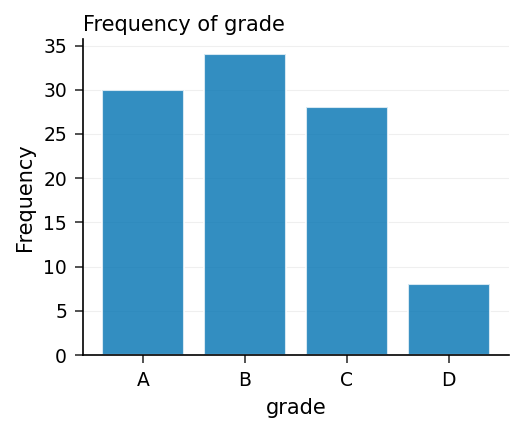

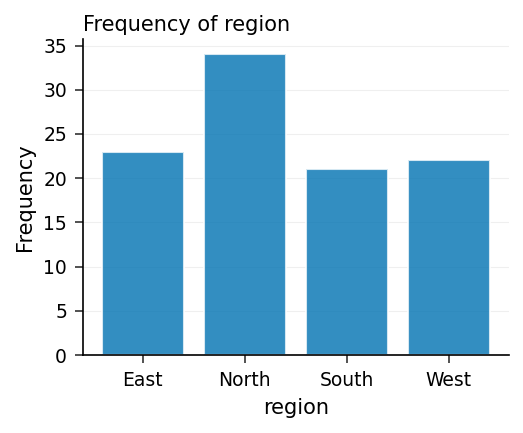

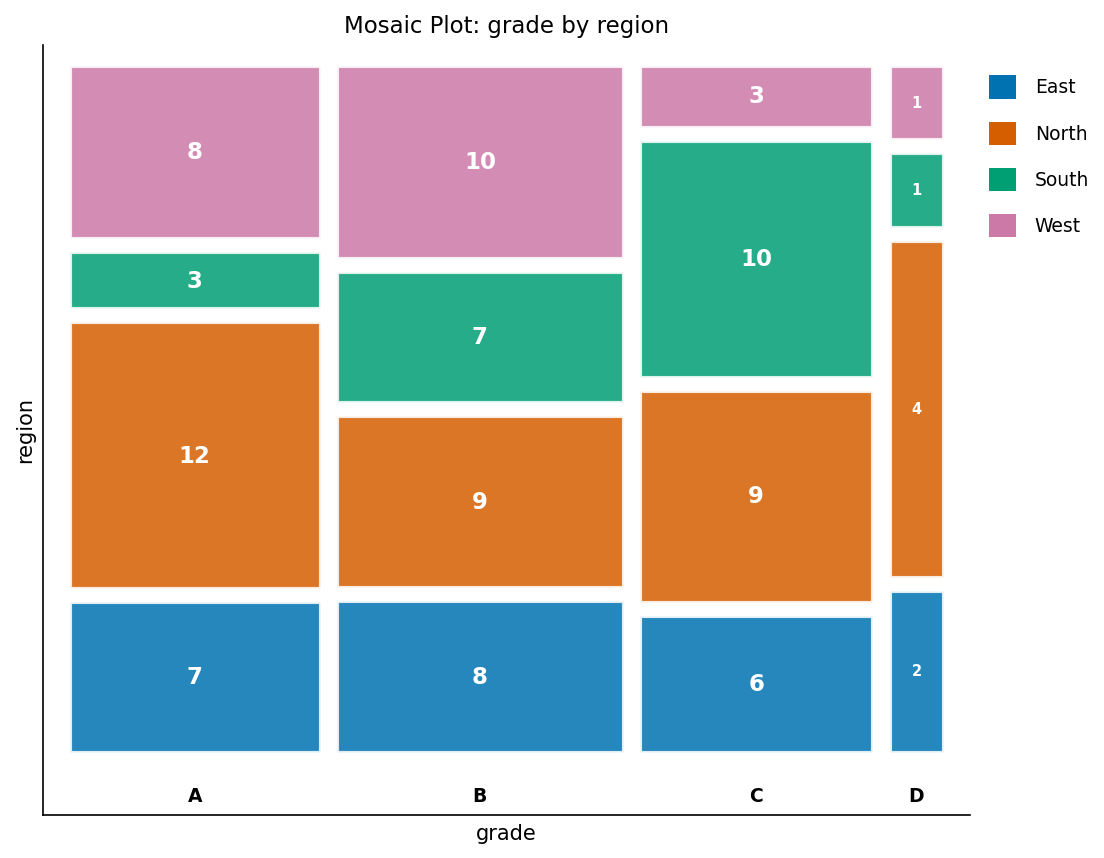

In [2]:
PROSEDUURI FREKVENSSIT TIEDOT=loans;
   TABLES grade region grade*region / nocum nopercent;
   NIMIKE grade="Luottoluokka" region="Alue";
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=loans n mean std MIN MAX maxdec=3;
   MUUTTUJA dti loan_amt lgd;
   NIMIKE dti="Velka-tulosuhde (DTI)" loan_amt="Lainan määrä (tuhatta USD)"
         lgd="Luottotappio-osuus (LGD)";
SUORITA;

## Vaihe 3 — Suunnittelumatriisin rakentaminen PROC GLMMOD:lla

Tämä on työnkulun ydin. `CLASS`-lauseke ilmoittaa muuttujat `grade` ja `region` luokitteleviksi muuttujiksi (sen **täytyy** edeltää `MODEL`-lauseketta). `MODEL`-lauseke nimeää selitettävän (`lgd`) ja vaikutukset:

- `grade region` — luokittelevat päävaikutukset (yksi GLM-koodattu sarake per taso)
- `dti loan_amt` — jatkuvat päävaikutukset (välitetään muuttumattomina)
- `grade*dti` — luottoluokkakohtainen DTI-kulmakerroin-yhdysvaikutus

Pyydämme kaksi tulosaineistoa:

- `OUTDESIGN=design` — yksi rivi per laina, GLM-koodatuilla numeerisilla sarakkeilla. Tätä `PROC REG` tulee käyttämään.
- `OUTPARM=parm` — yksi rivi per suunnittelusarake, joka kuvaa jokaisen sarakenumeron takaisin vaikutukseen ja luokan tasoon, jota se edustaa.

`ORDER=DATA` pitää luottoluokkien tasot järjestyksessä A-B-C-D, ja `PREFIX=X` nimeää suunnittelusarakkeet `X1, X2, ...`, jotta regression tuloste pysyy luettavana. GLM-koodaus on **ei-täysiasteinen**: neljä luottoluokan tasoa laajenevat neljäksi dummy-sarakkeeksi (ei kolmeksi), ja samoin alueelle ja yhdysvaikutukselle, joten matriisissa on tässä 15 saraketta — `X1` on GLMMOD:n oma vakiotermisarake, `X2-X5` luottoluokan dummy-muuttujat, `X6-X9` alue, `X10-X11` jatkuvat kovariaatit, ja `X12-X15` grade*dti-yhdysvaikutus.

In [3]:
PROSEDUURI glmmod TIEDOT=loans ORDER=TIEDOT PREFIX=X
            outdesign=design outparm=parm;
   LUOKKA grade region;
   MODEL lgd = grade region dti loan_amt grade*dti;
   NIMIKE grade="Luottoluokka" region="Alue" dti="Velka-tulosuhde (DTI)"
         loan_amt="Lainan määrä (tuhatta USD)" lgd="Luottotappio-osuus (LGD)";
SUORITA;

The GLMMOD Procedure


Number of Observations Read: 100
Number of Design Columns: 15    

                       Parameter Information                        

_COLNUM_  EFFNAME                             Luottoluokka  Alue    
--------  ----------------------------------  ------------  --------
1         Intercept                                                 
2         Luottoluokka                        C                     
3         Luottoluokka                        B                     
4         Luottoluokka                        D                     
5         Luottoluokka                        A                     
6         Alue                                              East    
7         Alue                                              South   
8         Alue                                              North   
9         Alue                                              West    
10        Velka-tulosuhde (DTI)                                     
11        La


NOTE: PROC GLMMOD data=loans

NOTE: PROC GLMMOD statement used.


## Vaihe 4 — Parametrikartan lukeminen

`OUTPARM=`-aineisto on suunnittelumatriisin selite: `_COLNUM_` on sarakenumero, `EFFNAME` on tuottava vaikutus, ja luokkamuuttujat näyttävät, minkä tason kukin sarake koodaa (tyhjä, kun vaikutus ei koske kyseistä luokkamuuttujaa). Riskianalyytikot käyttävät tätä sovitettujen kertoimien kääntämiseen takaisin liiketoiminnan käsitteiksi.

In [4]:
PROSEDUURI TULOSTA TIEDOT=parm noobs;
   OTSIKKO 'Suunnittelumatriisin sarakekartta (OUTPARM)';
SUORITA;
OTSIKKO;

                                      Suunnittelumatriisin sarakekartta (OUTPARM)                                       

_COLNUM_    EFFNAME  GRADE  REGION
       1  Intercept
       2  grade      C
       3  grade      B
       4  grade      D
       5  grade      A
       6  region            East
       7  region            South
       8  region            North
       9  region            West
      10  dti
      11  loan_amt
      12  grade*dti  C
      13  grade*dti  B
      14  grade*dti  D
      15  grade*dti  A




NOTE: PROC PRINT data=parm

NOTE: PROC PRINT completed: 15 observations printed, 4 variables


## Vaihe 5 — LGD-mallin sovitus PROC REG:llä suunnittelumatriisiin

Koska `PROC REG` ei voi itse laajentaa CLASS-vaikutuksia, syötämme sille GLM-koodatut sarakkeet `OUTDESIGN=`-aineistosta. `OUTDESIGN=`-aineisto sisältää vain suunnittelusarakkeet, joten liitämme ensin selitettävän `lgd`:n takaisin alkuperäisestä `loans`-aineistosta positionaalisella `MERGE`-lauseella (GLMMOD tuottaa yhden suunnittelurivin per syöterivi, syötejärjestyksessä, joten tämä on siisti yksi-yhteen-liitos). Sen jälkeen regressoimme `lgd`:n muuttujiin `X2--X15` käyttäen `--`-positionaalista nimialuetta, joka valitsee jokaisen muuttujan kahden nimetyn sarakkeen väliltä aineiston järjestyksessä. Ohitamme `X1`:n, koska se on GLMMOD:n oma vakiotermi-dummy ja `PROC REG` lisää jo oman vakiotermin; jäljelle jäävät yliparametroidut GLM-dummyt (yksi redundantti sarake per CLASS-vaikutus) havaitsee REG ja raportoi ei-estimoitavina / nollattuina termeinä — juuri sitä käytöstä, jota GLM-koodaukselta odotetaan.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                    Dependent Variable: lgd Luottotappio-osuus (LGD)                                    

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                  11         2.09623      0.19057     71.91    <.0001
Error                  88         0.23322      0.00265                    
Corrected Total        99         2.32945                                 

Root MSE           0.05148    R-Square            0.8999
Dependent Mean       0.37927    Adj R-Sq            0.8874
Coeff Var         13.57365

                       Parameter Estimates                       

Variable         DF  Estimate  Standard Error   t


NOTE: DATA design_lgd

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC REG data=design_lgd

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


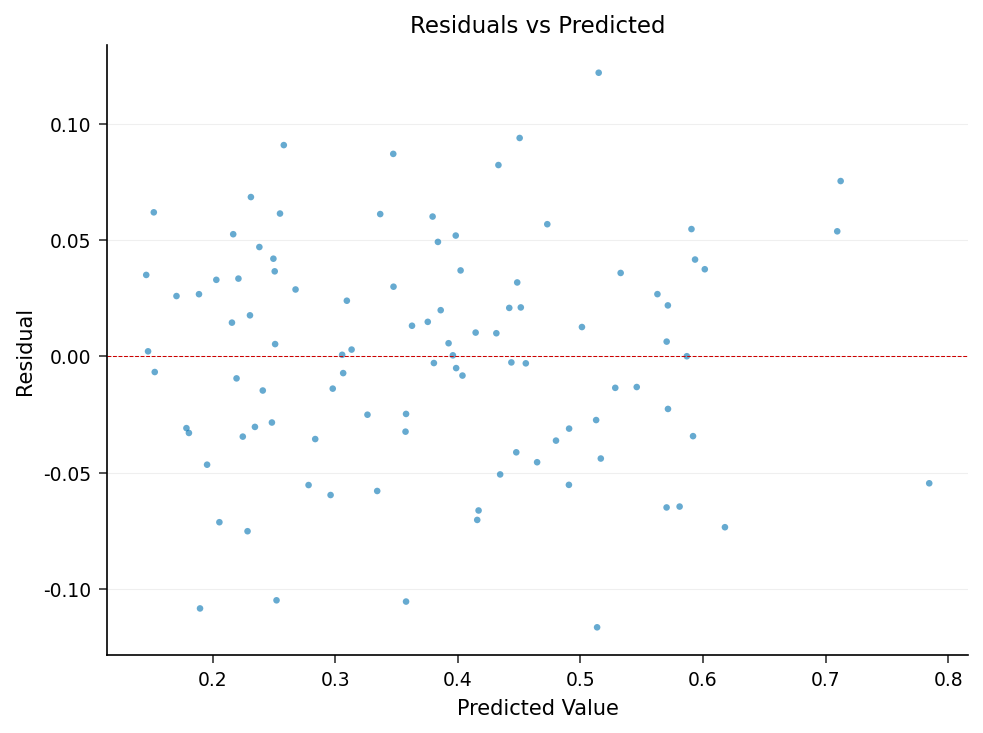

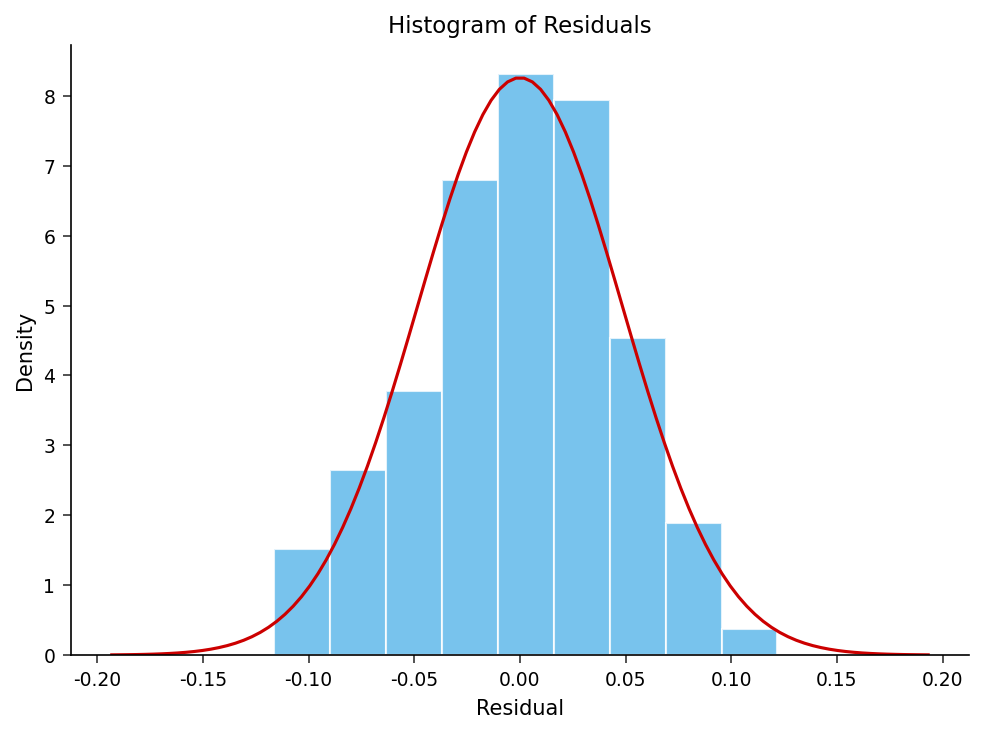

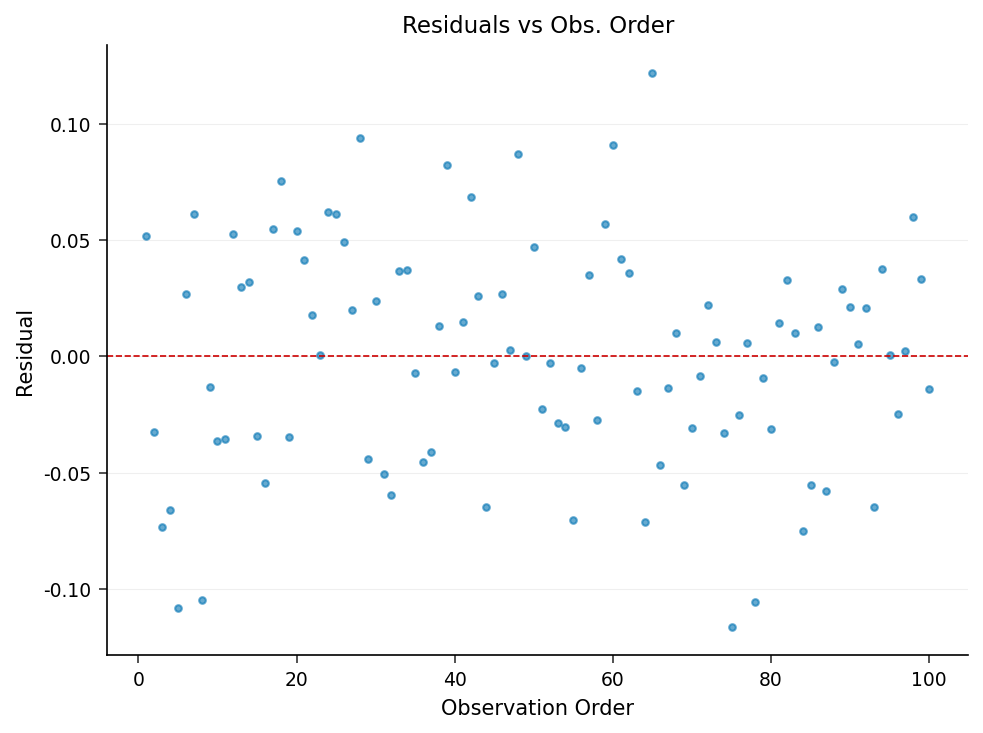

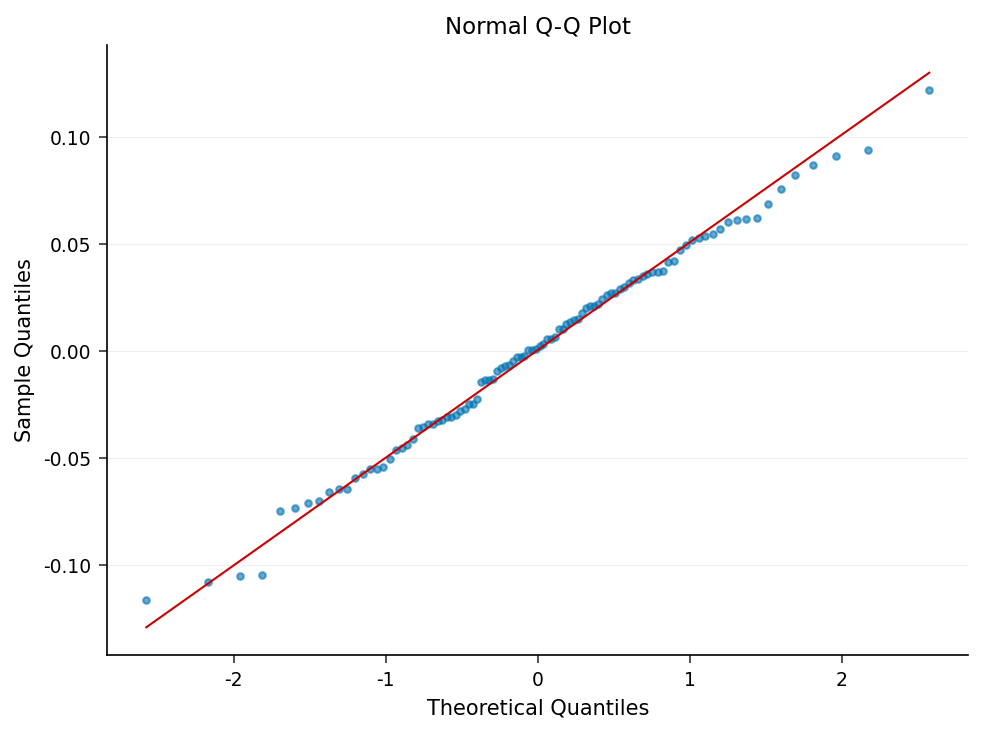

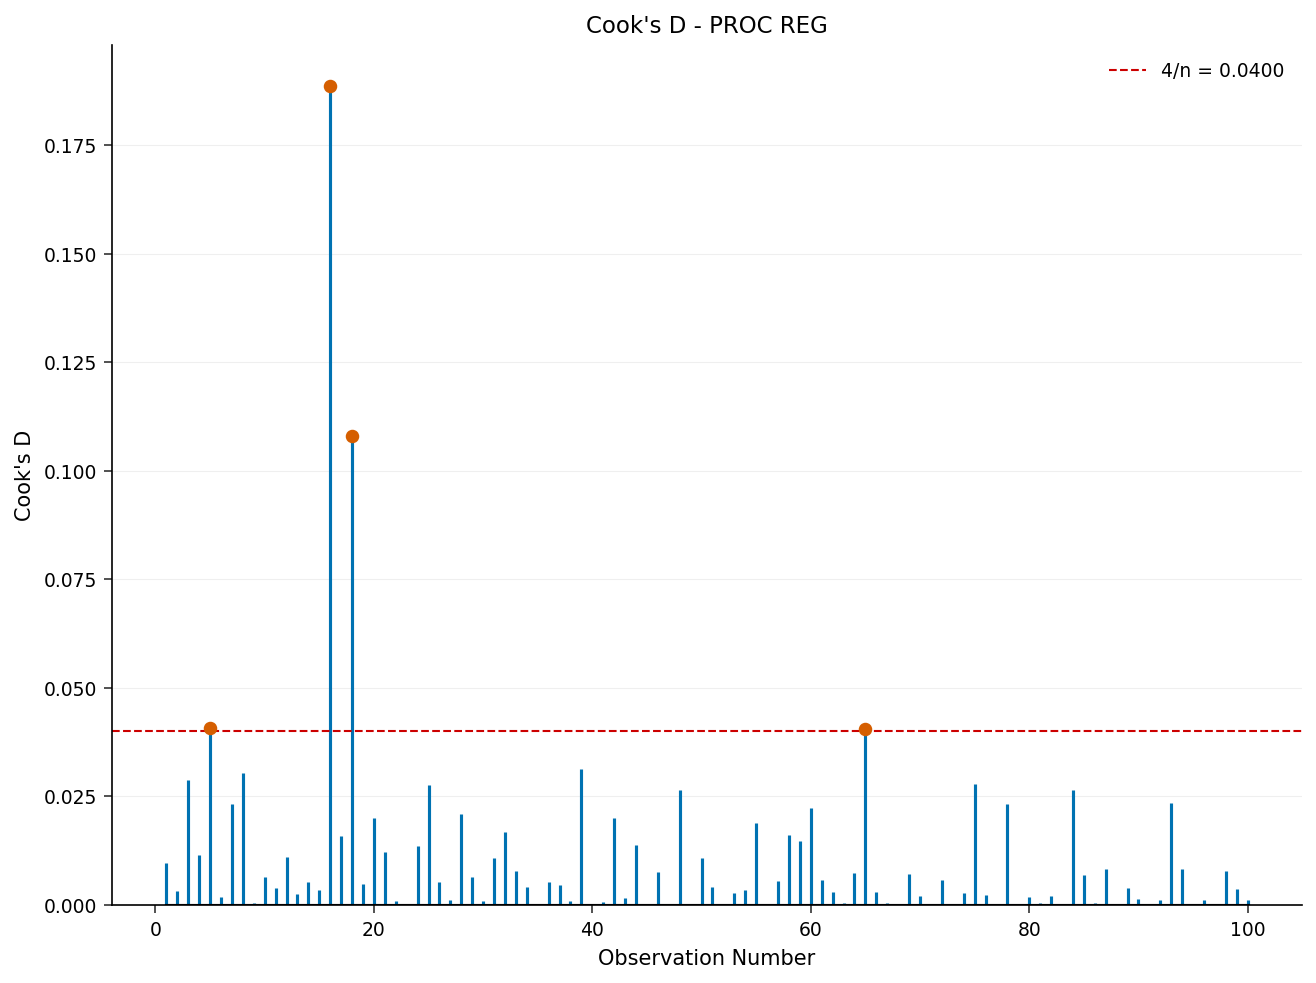

In [5]:
/* Re-attach the dependent (OUTDESIGN= carries only the design columns).
   GLMMOD writes one design row per input row in input order, so a
   positional MERGE rejoins lgd one-to-one. */
TIEDOT design_lgd;
   YHDISTÄ loans(SÄILYTÄ=lgd) design;
SUORITA;

PROSEDUURI REG TIEDOT=design_lgd;
   MODEL lgd = X2--X15;
   NIMIKE lgd="Luottotappio-osuus (LGD)";
SUORITA;
QUIT;

## Vaihe 6 — Toinen käyttötapaus: luottopolitiikan vipujen faktorikokeen seulonta

GLMMOD loistaa myös **kaksitasoisessa faktorikokeen seulonnassa**. Oletetaan, että luottopolitiikkakomitea ajaa 16-pisteisen osasuunnitelman viidelle binäärivivulle (tiukempi hinnoitteluvyöhyke, korkeampi pisteraja, matalampi DTI-katto, matalampi LTV-katto, lyhyempi enimmäislaina-aika) ja tallentaa portfolion `approval_rate`-vasteen. Haluamme seuloa kaikki päävaikutukset ja **kahden tekijän yhdysvaikutukset**.

`MODEL`-lausekkeen bar-operaattori asteen rajoituksella — `pricing|score_cut|dti_cap|ltv_cap|term_max@2` — laajenee jokaiseksi päävaikutukseksi ja jokaiseksi parittaiseksi yhdysvaikutukseksi (mutta ei kolmen tai useamman tekijän termeiksi). Tallennamme syntyvän suunnittelumatriisin komennolla `ODS OUTPUT DesignPoints=`.

In [6]:
TIEDOT screening;
   CALL streaminit(7);
   TEE pricing   = -1, 1;
   TEE score_cut = -1, 1;
   TEE dti_cap   = -1, 1;
   TEE ltv_cap   = -1, 1;
      term_max = pricing*score_cut*dti_cap*ltv_cap;  /* 2^(5-1)-generaattori */
      approval_rate = 62
         + 5.0*pricing  - 3.5*score_cut
         - 2.0*dti_cap  + 1.5*ltv_cap
         + 2.5*pricing*score_cut
         + 1.0*rand('Normal');
      TULOSTE;
   LOPPU; LOPPU; LOPPU; LOPPU;
SUORITA;


NOTE: DATA screening


NOTE: Wrote screening (16 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [7]:
ODS TULOSTE DesignPoints = screen_design;
PROSEDUURI glmmod TIEDOT=screening;
   MODEL approval_rate =
      pricing|score_cut|dti_cap|ltv_cap|term_max@2;
   NIMIKE approval_rate="Hyväksymisaste";
SUORITA;

The GLMMOD Procedure


Number of Observations Read: 16
Number of Design Columns: 16   

   Parameter Information    

_COLNUM_  EFFNAME           
--------  ------------------
1         Intercept         
2         pricing           
3         score_cut         
4         dti_cap           
5         ltv_cap           
6         term_max          
7         pricing*score_cut 
8         pricing*dti_cap   
9         pricing*ltv_cap   
10        pricing*term_max  
11        score_cut*dti_cap 
12        score_cut*ltv_cap 
13        score_cut*term_max
14        dti_cap*ltv_cap   
15        dti_cap*term_max  
16        ltv_cap*term_max  





NOTE: ODS OUTPUT: DESIGNPOINTS -> screen_design
NOTE: PROC GLMMOD data=screening

NOTE: PROC GLMMOD statement used.


## Vaihe 7 — Eteenpäin valitseva seulontaregressio

Kun seulonnan suunnittelumatriisi on käsillä, `PROC REG` suorittaa eteenpäin valinnan merkitäkseen, mitkä politiikkavivut ja yhdysvaikutukset todella liikuttavat hyväksymisastetta. Kuten vaiheessa 5, `ODS OUTPUT`-suunnittelusarjassa on vain suunnittelusarakkeet, joten liitämme positionaalisesti `approval_rate`-vasteen takaisin `screening`-aineistosta ennen regressiota. `--`-alue vetää sitten mukaan jokaisen bar-laajennuksen tuottaman suunnittelusarakkeen (`Col2--Col16`, ohittaen vakiotermi-dummyn `Col1`); `SELECTION=FORWARD` tuo termejä mukaan niin kauan kuin ne läpäisevät `SLENTRY=`-merkitsevyyskynnyksen.

In [8]:
/* Re-attach the response, then forward-select over the screening design. */
TIEDOT screen_fit;
   YHDISTÄ screening(SÄILYTÄ=approval_rate) screen_design;
SUORITA;

PROSEDUURI REG TIEDOT=screen_fit;
   MODEL approval_rate = Col2--Col16
      / selection = forward
        slentry   = 0.10
        details   = summary;
   NIMIKE approval_rate="Hyväksymisaste";
SUORITA;
QUIT;

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                   Dependent Variable: approval_rate Hyväksymisaste                                    

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   7       754.32503    107.76072   1049.87    <.0001
Error                   8         0.82113      0.10264                    
Corrected Total        15       755.14616                                 

Root MSE           0.32038    R-Square            0.9989
Dependent Mean      62.00253    Adj R-Sq            0.9980
Coeff Var          0.51672

                       Parameter Estimates                       

Variable         DF  Estimate  Standard Error   t 


NOTE: DATA screen_fit

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC REG data=screen_fit

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: PROC REG ODS Graphics generated.


## Tulosten tulkinta

- **Suunnittelumatriisin rakentaminen.** `PROC GLMMOD` muutti kahden CLASS-muuttujan, kahden jatkuvan kovariaatin ja luokka-jatkuva-yhdysvaikutuksen yhdistelmän yhdeksi 15-sarakkeiseksi numeeriseksi suunnittelumatriisiksi (`OUTDESIGN=design`) sekä ihmisluettavaksi sarakekartaksi (`OUTPARM=parm`). Tämä on kanoninen tapa antaa CLASS-lauseketta vailla olevalle proseduurille kuten `PROC REG` pääsy luokitteleviin ja yhdysvaikutuksiin. Koska `OUTDESIGN=` sisältää vain suunnittelusarakkeet, liitimme mallinnetun vasteen takaisin yksi-yhteen-positionaalisella `MERGE`-lauseella ennen regressiota.

- **LGD-malli.** 100 lainan otoksessa regressio muuttujiin `X2--X15` sopii hyvin — R-neliö 0.90, kokonais-F noin 72 (p < .0001). Sovitetut kertoimet palauttavat istutetun rakenteen: DTI:n päävaikutuksen kulmakerroin `X10` on suuri ja erittäin merkitsevä (noin 0.37), `loan_amt` (`X11`) on positiivinen ja merkitsevä, ja heikoimman luottoluokan grade*dti-yhdysvaikutussarake (`X14`) kantaa jyrkimmän lisäkulmakertoimen — DTI-riskikulmakerroin jyrkkenee heikommilla luottoluokilla, aivan kuten simuloitiin. Yksi GLM-koodattu dummy jokaisen CLASS-vaikutuksen sisällä on rakenteellisesti redundantti; REG raportoi yliparametroidut termit tämän mukaisesti.

- **Politiikan seulonta.** `@2`-bar-laajennus antoi komitealle päävaikutus-plus-kaksisuuntaisen suunnitelman ilman, että 15 yhdysvaikutustermiä täytyi kirjoittaa käsin. Eteenpäin valinta toi mukaan `pricing`-vivun (suurin positiivinen vaikutus, noin +4.8), `score_cut`:n (negatiivinen, noin -3.6), `pricing*score_cut`-synergian (noin +2.2), `dti_cap`:n (negatiivinen) ja `ltv_cap`:n (positiivinen) — palauttaen kaikki simuloidun vasteen aktiiviset termit ja jättäen inertit korkeamman asteen termit pois (R-neliö 0.999) — tiivis, perusteltavissa oleva tarina luottopolitiikan muistioon.

**Johtopäätös:** `PROC GLMMOD` on harvoin lopullinen analyysi, mutta se on silta, joka antaa yksinkertaisten, läpinäkyvien regressioproseduurien mallintaa luokittelevaa ja yhdysvaikutusrakennetta, jota todellinen pankkidata aina sisältää.